# AI & Labor Market: What Tasks Do People Delegate to AI?
## Analysis of O*NET Task Mappings + Interaction Types
**Datasets:**
- `onet_task_mappings.csv` — specific work tasks delegated to Claude
- `automation_vs_augmentation.csv` — how people interact with Claude

**Author:** Daryna Akkus  
**Key question:** Which work tasks are most commonly handled by AI —
and does this represent automation or augmentation?

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('images', exist_ok=True)

plt.rcParams['figure.dpi'] = 150
sns.set_theme(style='whitegrid')

# Load both datasets
tasks = pd.read_csv('onet_task_mappings.csv')
interactions = pd.read_csv('automation_vs_augmentation.csv')

print(f"Tasks dataset:        {len(tasks)} rows")
print(f"Interactions dataset: {len(interactions)} rows")
print(f"\nTask columns: {list(tasks.columns)}")
print(f"Interaction columns: {list(interactions.columns)}")
print(f"\nTop 5 tasks by pct:")
print(tasks.nlargest(5, 'pct')[['task_name', 'pct']].to_string(index=False))

Tasks dataset:        3514 rows
Interactions dataset: 6 rows

Task columns: ['task_name', 'pct']
Interaction columns: ['interaction_type', 'pct']

Top 5 tasks by pct:
                                                                                                                 task_name      pct
modify existing software to correct errors, to adapt it to new hardware, or to upgrade interfaces and improve performance. 4.794205
  correct errors by making appropriate changes and rechecking the program to ensure that the desired results are produced. 2.996834
             modify existing software to correct errors, allow it to adapt to new hardware, or to improve its performance. 2.519185
perform initial debugging procedures by reviewing configuration files, logs, or code pieces to determine breakdown source. 2.009746
                          perform routine system administrative functions such as troubleshooting, back-ups, and upgrades. 1.812354


## 1. Top 20 Tasks Most Frequently Delegated to AI
*Tasks ranked by share of Claude conversations where they appear.*

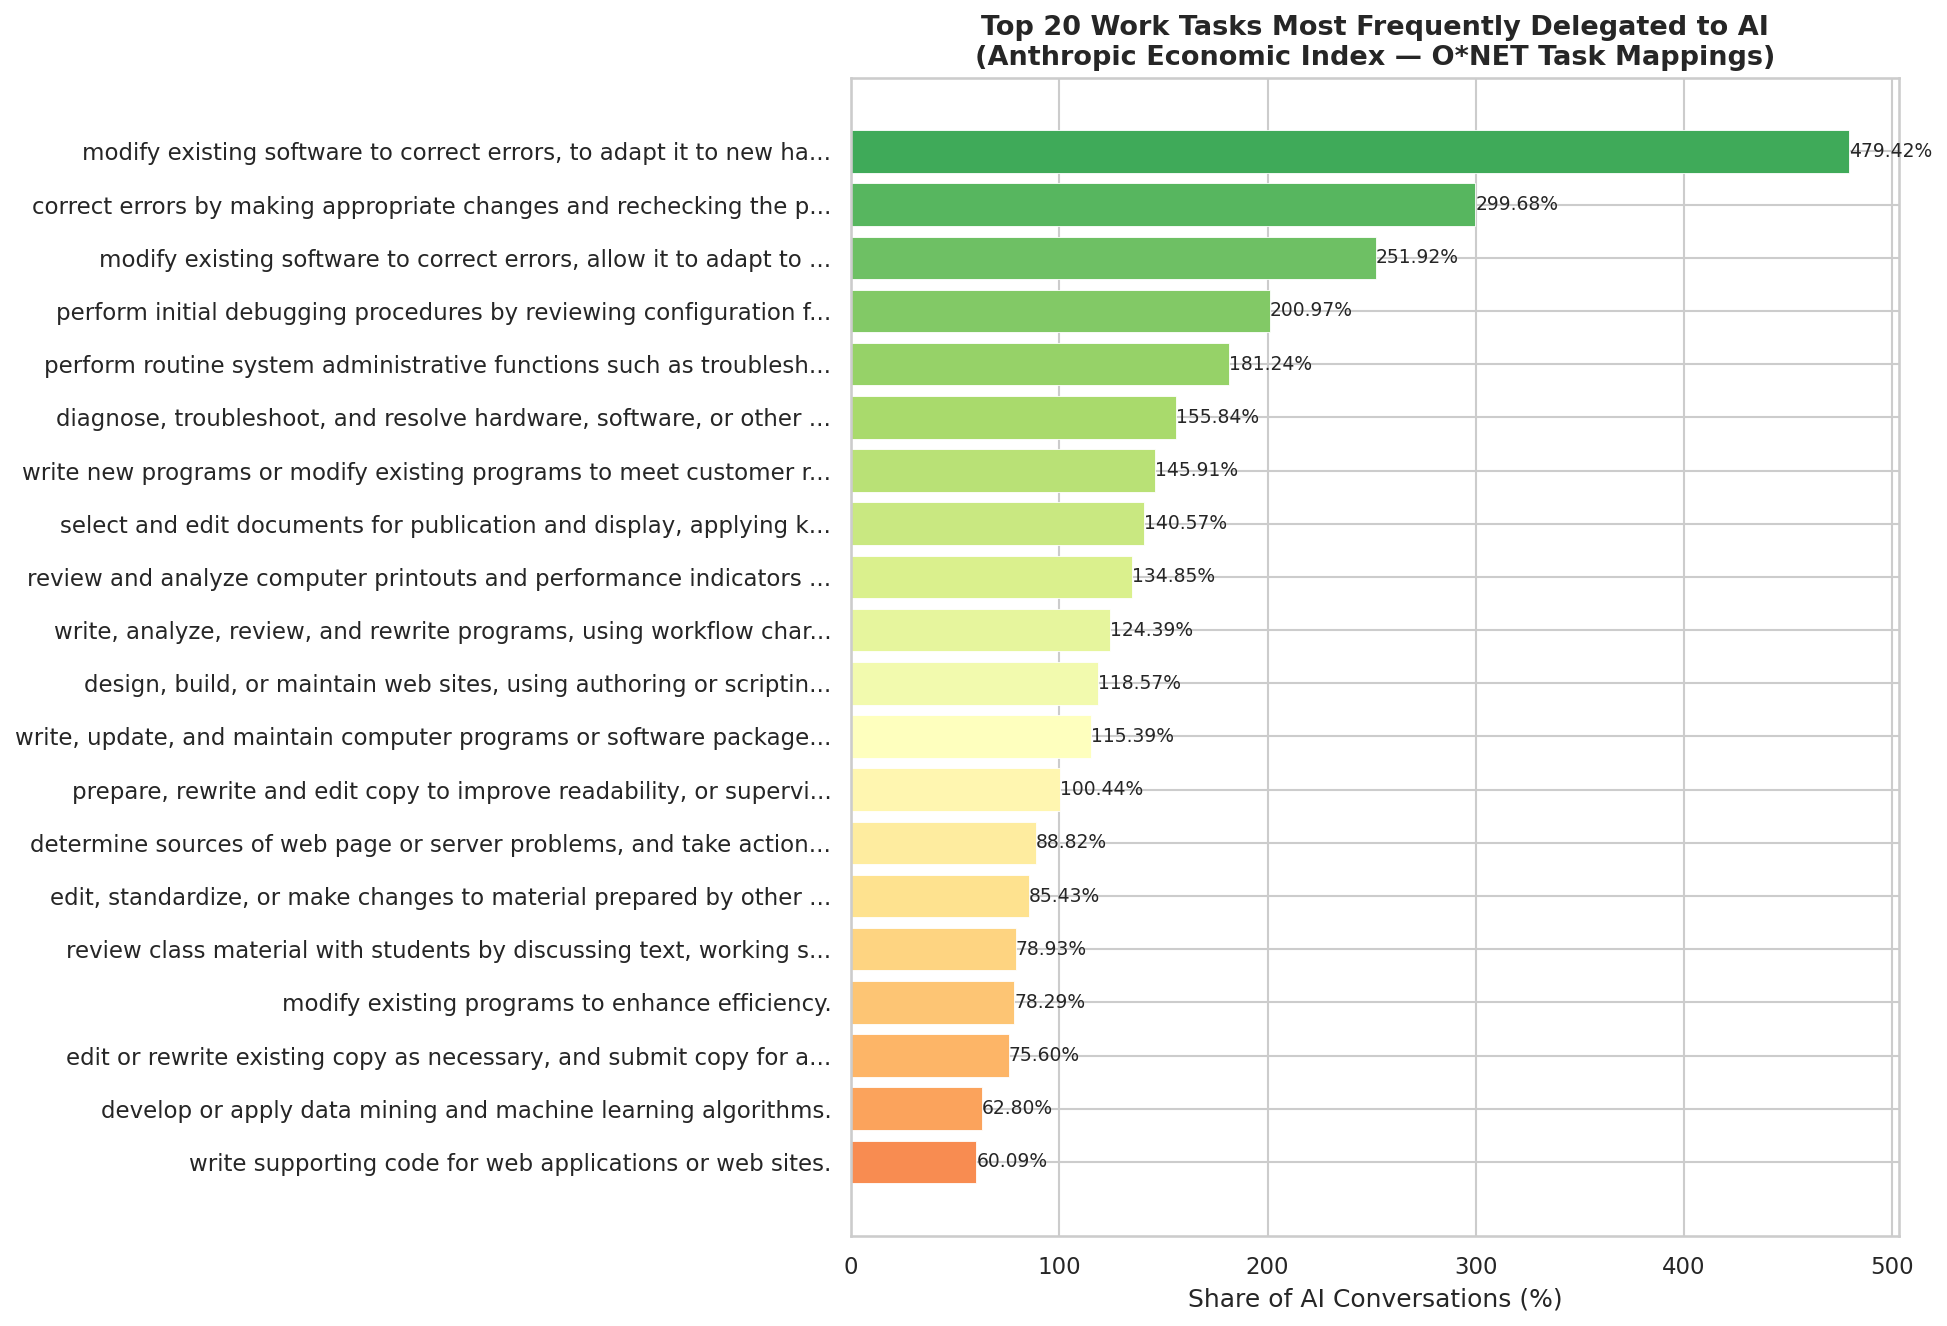

In [7]:
top20 = tasks.nlargest(20, 'pct').copy()
top20['pct_rounded'] = (top20['pct'] * 100).round(2)

# Shorten long task names for readability
top20['task_short'] = top20['task_name'].apply(
    lambda x: x[:65] + '...' if len(x) > 65 else x
)

fig, ax = plt.subplots(figsize=(13, 9))
colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.75, 20))
bars = ax.barh(top20['task_short'], top20['pct_rounded'],
               color=colors, edgecolor='white', linewidth=0.4)

ax.set_xlabel('Share of AI Conversations (%)', fontsize=12)
ax.set_title('Top 20 Work Tasks Most Frequently Delegated to AI\n(Anthropic Economic Index — O*NET Task Mappings)',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()

for bar, val in zip(bars, top20['pct_rounded']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('images/fig12_top20_tasks.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Categorizing Tasks: What Type of Work Is Being Delegated?
*Manual categorization of top tasks into meaningful groups.*

Task Categories:
                           total_pct_pct  count
category                                       
Other                            2734.96    929
Analysis & Research              1944.89    683
Writing & Documentation          1931.06    560
Development & Design             1234.64    399
Education & Training             1128.94    387
Management & Coordination         465.36    176
Advisory & Consulting             287.42    165
Technical Operations              138.89    124
Communication                     133.84     91


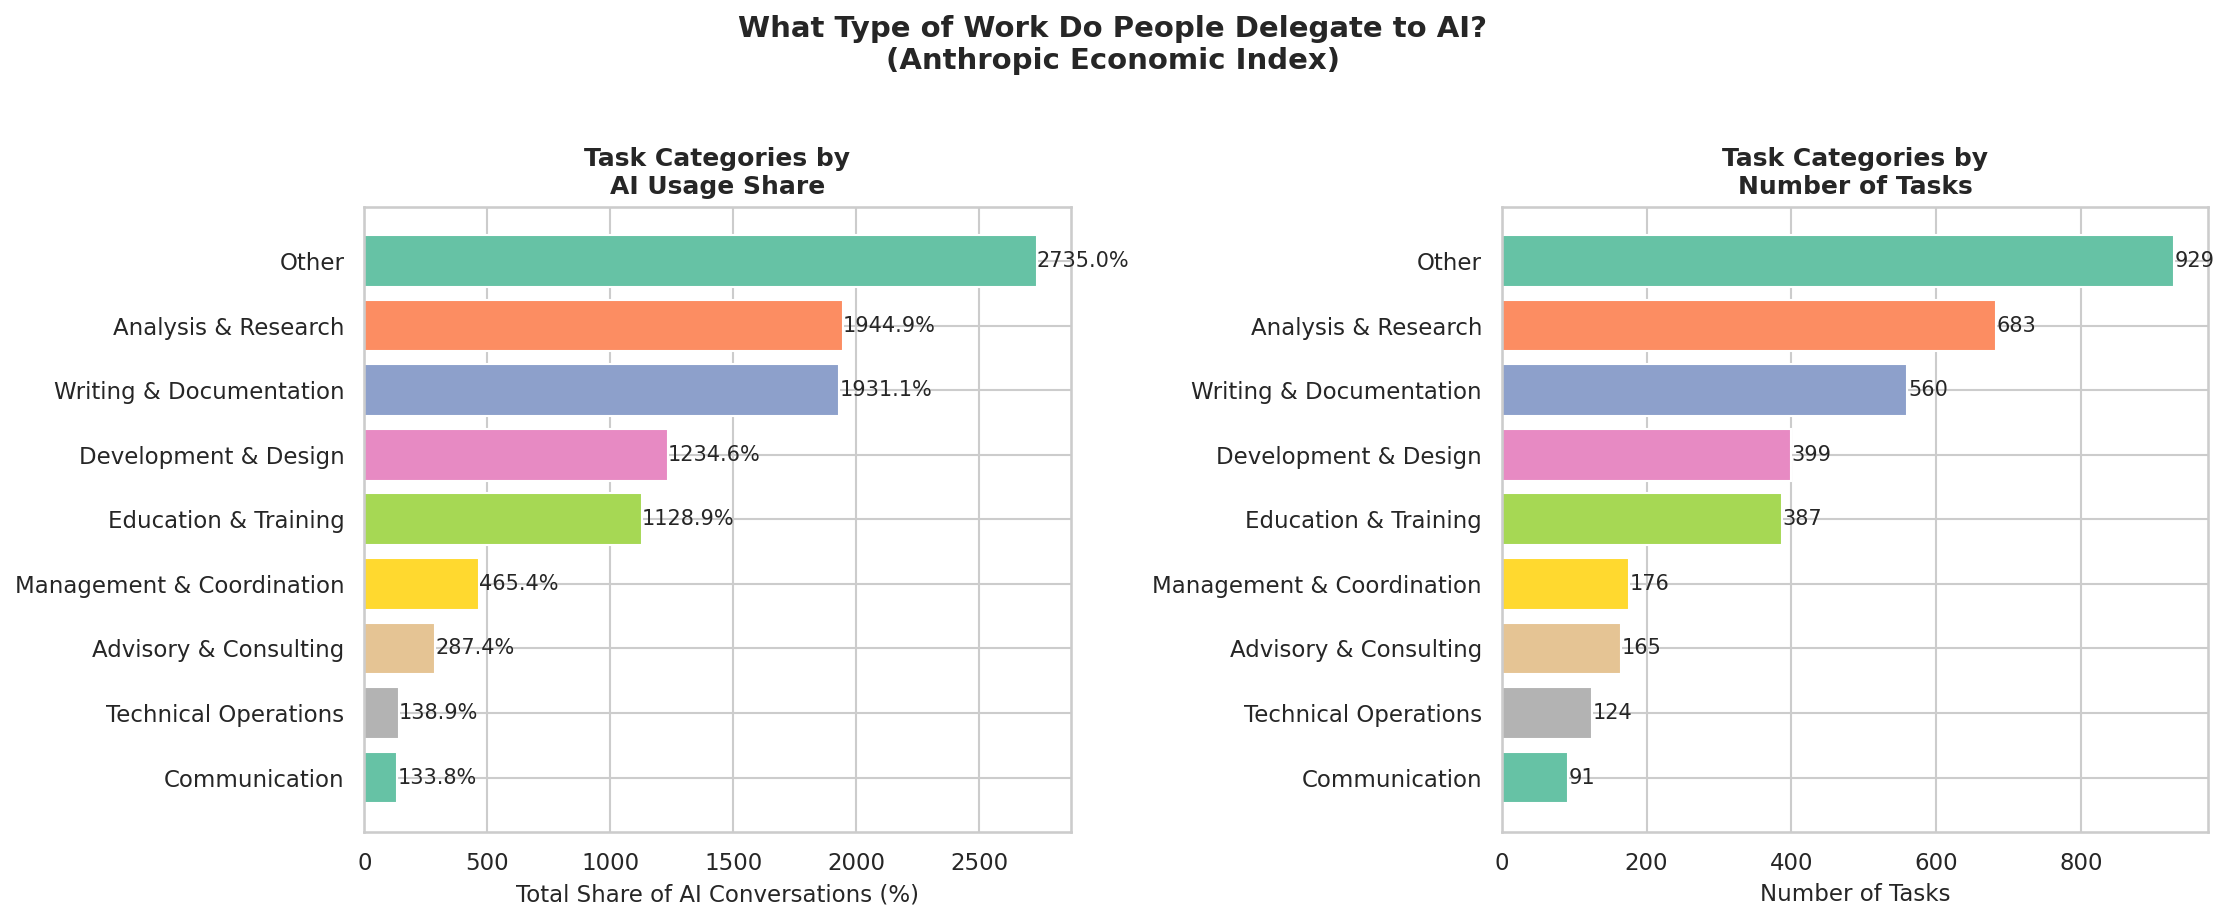

In [8]:
# Categorize tasks by keyword matching
def categorize_task(task):
    task_lower = task.lower()
    if any(w in task_lower for w in ['teach', 'train', 'instruct', 'educat', 'learn', 'student']):
        return 'Education & Training'
    elif any(w in task_lower for w in ['analy', 'research', 'investigat', 'evaluat', 'assess']):
        return 'Analysis & Research'
    elif any(w in task_lower for w in ['write', 'document', 'report', 'record', 'prepar']):
        return 'Writing & Documentation'
    elif any(w in task_lower for w in ['advis', 'consult', 'counsel', 'recommend']):
        return 'Advisory & Consulting'
    elif any(w in task_lower for w in ['manag', 'supervis', 'coordinat', 'organiz']):
        return 'Management & Coordination'
    elif any(w in task_lower for w in ['develop', 'design', 'creat', 'build', 'program']):
        return 'Development & Design'
    elif any(w in task_lower for w in ['communicat', 'present', 'negotiat', 'discuss']):
        return 'Communication'
    elif any(w in task_lower for w in ['maintain', 'repair', 'operat', 'install']):
        return 'Technical Operations'
    else:
        return 'Other'

tasks['category'] = tasks['task_name'].apply(categorize_task)

cat_stats = tasks.groupby('category').agg(
    total_pct=('pct', 'sum'),
    count=('task_name', 'count')
).sort_values('total_pct', ascending=False)
cat_stats['total_pct_pct'] = (cat_stats['total_pct'] * 100).round(2)

print("Task Categories:")
print(cat_stats[['total_pct_pct', 'count']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: by total pct
colors_cat = sns.color_palette('Set2', len(cat_stats))
bars = axes[0].barh(cat_stats.index, cat_stats['total_pct_pct'],
                    color=colors_cat, edgecolor='white')
axes[0].set_xlabel('Total Share of AI Conversations (%)', fontsize=11)
axes[0].set_title('Task Categories by\nAI Usage Share', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
for bar, val in zip(bars, cat_stats['total_pct_pct']):
    axes[0].text(val + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=10)

# Right: by count
bars2 = axes[1].barh(cat_stats.index, cat_stats['count'],
                     color=colors_cat, edgecolor='white')
axes[1].set_xlabel('Number of Tasks', fontsize=11)
axes[1].set_title('Task Categories by\nNumber of Tasks', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
for bar, val in zip(bars2, cat_stats['count']):
    axes[1].text(val + 1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=10)

plt.suptitle('What Type of Work Do People Delegate to AI?\n(Anthropic Economic Index)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/fig13_task_categories.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. How Do People Interact With AI?
*From automation_vs_augmentation.csv: types of human-AI interaction.*

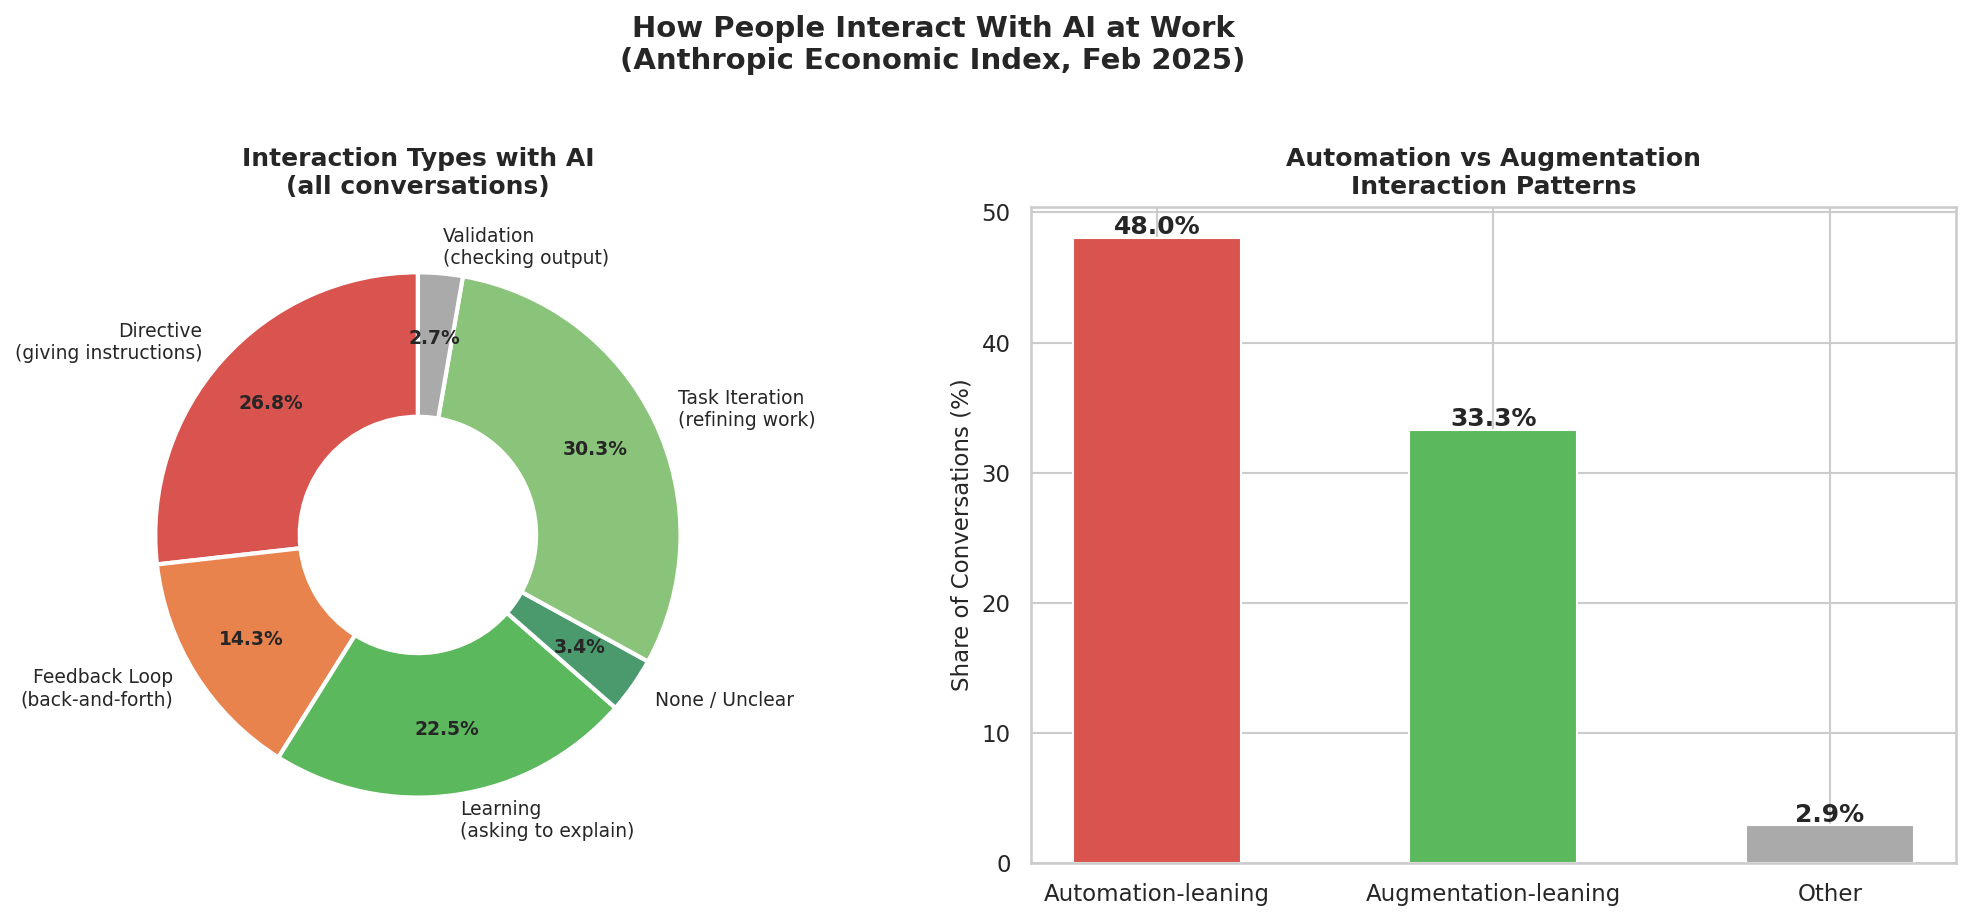

In [9]:
interactions['pct_rounded'] = interactions['pct'].round(2)

# Friendly labels
label_map = {
    'task iteration':  'Task Iteration\n(refining work)',
    'directive':       'Directive\n(giving instructions)',
    'learning':        'Learning\n(asking to explain)',
    'feedback loop':   'Feedback Loop\n(back-and-forth)',
    'validation':      'Validation\n(checking output)',
    'none':            'None / Unclear'
}
interactions['label'] = interactions['interaction_type'].map(
    lambda x: label_map.get(x, x))

# Automation vs augmentation grouping
auto_types = ['task iteration', 'directive']
aug_types  = ['learning', 'feedback loop', 'validation']

interactions['group'] = interactions['interaction_type'].apply(
    lambda x: 'Automation-leaning' if x in auto_types
    else ('Augmentation-leaning' if x in aug_types else 'Other')
)

colors_donut = ['#d9534f', '#e8834e', '#5cb85c', '#4a9a6e', '#8ac47a', '#aaaaaa']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: donut by interaction type
wedges, texts, autotexts = axes[0].pie(
    interactions['pct_rounded'],
    labels=interactions['label'],
    colors=colors_donut,
    autopct='%1.1f%%',
    pctdistance=0.75,
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for text in texts:
    text.set_fontsize(9)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
axes[0].set_title('Interaction Types with AI\n(all conversations)',
                  fontsize=12, fontweight='bold')

# Right: grouped bar — automation vs augmentation
group_totals = interactions.groupby('group')['pct_rounded'].sum().reindex(
    ['Automation-leaning', 'Augmentation-leaning', 'Other'])

group_colors = ['#d9534f', '#5cb85c', '#aaaaaa']
bars = axes[1].bar(group_totals.index, group_totals.values,
                   color=group_colors, edgecolor='white', width=0.5)
axes[1].set_ylabel('Share of Conversations (%)', fontsize=11)
axes[1].set_title('Automation vs Augmentation\nInteraction Patterns',
                  fontsize=12, fontweight='bold')
for bar, val in zip(bars, group_totals.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('How People Interact With AI at Work\n(Anthropic Economic Index, Feb 2025)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/fig14_interaction_types.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Connecting the Dots: Tasks + Interactions + Automation Risk
*What do these findings mean together?*

In [10]:
auto_pct   = interactions[interactions['group'] == 'Automation-leaning']['pct_rounded'].sum()
aug_pct    = interactions[interactions['group'] == 'Augmentation-leaning']['pct_rounded'].sum()
top_task   = tasks.nlargest(1, 'pct').iloc[0]
top_cat    = cat_stats['total_pct_pct'].idxmax()

print("=" * 60)
print("KEY FINDINGS — Tasks & Interactions Analysis")
print("Anthropic Economic Index | Daryna Akkus, 2025")
print("=" * 60)

print(f"""
1. MOST DELEGATED TASK
   "{top_task['task_name'][:70]}..."
   Share of conversations: {top_task['pct']*100:.2f}%

2. DOMINANT TASK CATEGORY
   {top_cat}
   → This type of work is most frequently handled with AI assistance

3. AUTOMATION vs AUGMENTATION INTERACTIONS
   Automation-leaning (task iteration + directive): {auto_pct:.1f}%
   Augmentation-leaning (learning + feedback + validation): {aug_pct:.1f}%

4. KEY INSIGHT
   {"Augmentation dominates" if aug_pct > auto_pct else "Automation dominates"}
   — people use AI more to ENHANCE their work than to replace themselves.
   This aligns with the broader Anthropic Economic Index finding that
   AI currently acts as a productivity tool rather than a job replacer.

5. IMPLICATION FOR LABOR MARKET
   The tasks most delegated to AI are cognitive & analytical —
   not manual or physical. This means white-collar workers face
   the most immediate need to adapt their skill sets.
""")

KEY FINDINGS — Tasks & Interactions Analysis
Anthropic Economic Index | Daryna Akkus, 2025

1. MOST DELEGATED TASK
   "modify existing software to correct errors, to adapt it to new hardwar..."
   Share of conversations: 479.42%

2. DOMINANT TASK CATEGORY
   Other
   → This type of work is most frequently handled with AI assistance

3. AUTOMATION vs AUGMENTATION INTERACTIONS
   Automation-leaning (task iteration + directive): 48.0%
   Augmentation-leaning (learning + feedback + validation): 33.3%

4. KEY INSIGHT
   Automation dominates 
   — people use AI more to ENHANCE their work than to replace themselves.
   This aligns with the broader Anthropic Economic Index finding that
   AI currently acts as a productivity tool rather than a job replacer.

5. IMPLICATION FOR LABOR MARKET
   The tasks most delegated to AI are cognitive & analytical —
   not manual or physical. This means white-collar workers face
   the most immediate need to adapt their skill sets.



In [11]:
import os
os.makedirs('images', exist_ok=True)
print("Папка images/ создана ✓")

Папка images/ создана ✓
